<a href="https://colab.research.google.com/github/rafaelromwno/am-t4-s1a2026/blob/main/aula-15/NeuralNetworkCensus0611.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pipeline Carregamento de Dados | Neural Network Base [Fase 1 - census_data]

## Importar dados do Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bibliotecas de Python

In [2]:
!pip -q install plotly
!pip -q install yellowbrick

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Carregar Digest de base_census

In [4]:
import pickle

In [5]:
with open('/content/drive/MyDrive/Eu/FATEC/CICLO-V/ML/P1/census.pkl', mode = 'rb') as f:
   X_census_treinamento, Y_census_treinamento, X_census_teste, Y_census_teste = pickle.load(f)

In [6]:
X_census_treinamento.shape, Y_census_treinamento.shape

((27676, 108), (27676,))

In [7]:
X_census_teste.shape, Y_census_teste.shape

((4885, 108), (4885,))

# Pipeline Neural Network | Neural Network Base [Fase 2 - census_data]

## Treinamento da Rede Neural

In [8]:
from sklearn.neural_network import MLPClassifier

In [9]:
rede_neural_census_data = MLPClassifier(

    hidden_layer_sizes=(55, 55),

    max_iter=1000,

    random_state=1
)

rede_neural_census_data.fit(
    X_census_treinamento,
    Y_census_treinamento
)

MLPClassifier(hidden_layer_sizes=(55, 55), max_iter=1000, random_state=1)

In [10]:
modelo = MLPClassifier(

    hidden_layer_sizes=(55, 55),   # neuronios por camada oculta

    activation='relu',             # funcao de ativacao (relu, tanh, logistic)

    solver='adam',                 # otimizador dos pesos

    max_iter=1000,                 # numero maximo de epocas

    batch_size='auto',             # tamanho do lote por atualizacao

    learning_rate_init=0.001,      # taxa de aprendizado inicial

    early_stopping=False,          # interrompe se nao houver melhora na validacao

    random_state=1                 # garante reproducibilidade dos resultados
)

# Pipeline Medicoes Harmonicas | Neural Network Base [Fase 3 - census_data]

## Avaliacao da Rede Neural

In [11]:
previsoes_rede_neural = rede_neural_census_data.predict(X_census_teste)

In [12]:
previsoes_rede_neural

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      dtype='<U6')

In [13]:
Y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [15]:
accuracy_score(Y_census_teste, previsoes_rede_neural)

0.8077789150460594

In [16]:
from yellowbrick.classifier import ConfusionMatrix

In [17]:
print(classification_report(Y_census_teste, previsoes_rede_neural))

              precision    recall  f1-score   support

       <=50K       0.88      0.86      0.87      3693
        >50K       0.60      0.64      0.62      1192

    accuracy                           0.81      4885
   macro avg       0.74      0.75      0.75      4885
weighted avg       0.81      0.81      0.81      4885



0.8077789150460594

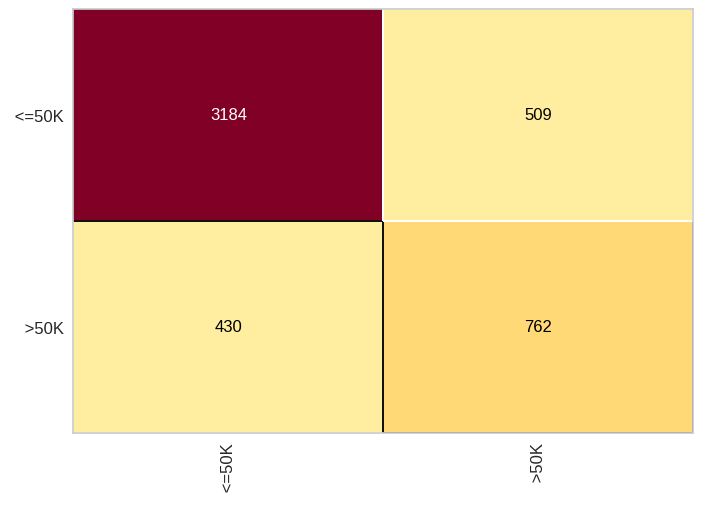

In [18]:
cm_census_rede_neural = ConfusionMatrix(rede_neural_census_data)
cm_census_rede_neural.fit(X_census_treinamento, Y_census_treinamento)
cm_census_rede_neural.score(X_census_teste, Y_census_teste)